In [19]:
# setup folders
import os
import shutil

os.makedirs("/kaggle/working/signal_processing", exist_ok=True)

SOURCE_DIR = "/kaggle/input/datasets/emanmansour7/preprocessing-files"

files = [
    "__init__.py",
    "filters.py",
    "iq_processor.py",
    "signal_generator.py",
    "simulator.py",
    "stft.py",
    "spectrogram.py"
]

for f in files:
    shutil.copy(
        os.path.join(SOURCE_DIR, f),
        f"/kaggle/working/signal_processing/{f}"
    )

print("Files copied")

Files copied


In [20]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".py"):
            print(os.path.join(root, file))

/kaggle/input/datasets/emanmansour7/preprocessing-files/signal_generator.py
/kaggle/input/datasets/emanmansour7/preprocessing-files/simulator.py
/kaggle/input/datasets/emanmansour7/preprocessing-files/iq_processor.py
/kaggle/input/datasets/emanmansour7/preprocessing-files/stft.py
/kaggle/input/datasets/emanmansour7/preprocessing-files/spectrogram.py
/kaggle/input/datasets/emanmansour7/preprocessing-files/filters.py
/kaggle/input/datasets/emanmansour7/preprocessing-files/__init__.py


In [21]:
!pip install scipy -q
print("Done")

Done


In [24]:
import os
import sys
import h5py
import numpy as np
import gc
from sklearn.model_selection import train_test_split

# Setup workspace environment
sys.path.insert(0, "/kaggle/working")
from signal_processing.signal_generator import generate_signal
from signal_processing.spectrogram import generate_spectrogram

# Configuration & Constants
DATA_PATH = "/kaggle/input/datasets/pinxau1000/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5"
SAMPLES_PER_CLASS = 5000

# ============================================
# 1. RadioML Data Extraction (Baseline)
# ============================================
print("Extracting RadioML baseline samples...")
with h5py.File(DATA_PATH, "r") as f:
    # Scan first 100k samples for high SNR (>= 6dB)
    snr_check_limit = 100000
    Z_temp = f["Z"][:snr_check_limit]
    
    # Filter indices based on SNR threshold
    mask = np.where(Z_temp >= 6)[0]
    
    # Randomly select required samples and sort for sequential I/O performance
    selected_indices = np.random.choice(mask, SAMPLES_PER_CLASS, replace=False)
    selected_indices = sorted(selected_indices) 
    normal_iq = f["X"][selected_indices]
    
print(f"Normal IQ data loaded: {normal_iq.shape} ✅")

# ============================================
# 2. Synthetic Signal Generation (Simulator)
# ============================================
print("Simulating Jamming signals...")
jamming_iq = np.array([
    generate_signal("jamming", num_samples=1024, seed=i)
    for i in range(SAMPLES_PER_CLASS)
])

print("Simulating Drone signals...")
drone_iq = np.array([
    generate_signal("drone", num_samples=1024, seed=i+10000)
    for i in range(SAMPLES_PER_CLASS)
])

print(f"Jamming data: {jamming_iq.shape} ✅")
print(f"Drone data:   {drone_iq.shape} ✅")

# ============================================
# 3. IQ to Spectrogram Conversion (Memory Optimized)
# ============================================
def iq_to_complex(iq):
    """Convert interleaved IQ channels to complex64 array."""
    return (iq[:, 0] + 1j * iq[:, 1]).astype(np.complex64)

def process_batch(iq_batch, label_id, label_name):
    """Processes signals in chunks to prevent RAM overflow."""
    chunk_size = 500
    all_specs = []
    total = len(iq_batch)
    
    for start in range(0, total, chunk_size):
        end = min(start + chunk_size, total)
        current_chunk = iq_batch[start:end]
        
        specs = []
        for iq in current_chunk:
            # Handle complex signals vs interleaved raw data
            if np.iscomplexobj(iq):
                signal = iq.astype(np.complex64)
            else:
                signal = iq_to_complex(iq)
            
            # Generate 224x224x3 spectrogram
            spec = generate_spectrogram(signal)
            specs.append(spec)
            
        # Stack current chunk and append to results list
        all_specs.append(np.array(specs, dtype=np.float32))
        
        # Explicit memory cleanup
        del specs
        gc.collect() 
        print(f"  {label_name}: {end}/{total} processed...")

    # Final concatenation for the class
    final_specs = np.concatenate(all_specs, axis=0)
    final_labels = np.array([label_id] * total, dtype=np.int32)
    
    del all_specs
    gc.collect()
    
    return final_specs, final_labels

print("\nStarting IQ-to-Spectrogram conversion...")
X_normal,  y_normal  = process_batch(normal_iq,  0, "Normal")
X_jamming, y_jamming = process_batch(jamming_iq, 1, "Jamming")
X_drone,   y_drone   = process_batch(drone_iq,   2, "Drone")

# ============================================
# 4. Data Consolidation, Shuffling & Partitioning
# ============================================
# Merge all classes into a single dataset
X_all = np.concatenate([X_normal, X_jamming, X_drone])
y_all = np.concatenate([y_normal, y_jamming, y_drone])

# Free individual class buffers to maximize RAM for split operation
del X_normal, X_jamming, X_drone, y_normal, y_jamming, y_drone
gc.collect()

# Randomize dataset order
idx = np.random.permutation(len(X_all))
X_all, y_all = X_all[idx], y_all[idx]

# Split: 70% Train, 15% Val, 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.3, stratify=y_all, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# Export processed data to working directory
os.makedirs("/kaggle/working/dataset", exist_ok=True)
np.save("/kaggle/working/dataset/X_train.npy", X_train)
np.save("/kaggle/working/dataset/X_val.npy",   X_val)
np.save("/kaggle/working/dataset/X_test.npy",  X_test)
np.save("/kaggle/working/dataset/y_train.npy", y_train)
np.save("/kaggle/working/dataset/y_val.npy",   y_val)
np.save("/kaggle/working/dataset/y_test.npy",  y_test)

print("\n✅ Dataset generation complete!")
print(f"Training set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Testing set:    {X_test.shape}")

Extracting RadioML baseline samples...
Normal IQ data loaded: (5000, 1024, 2) ✅
Simulating Jamming signals...
Simulating Drone signals...
Jamming data: (5000, 1024) ✅
Drone data:   (5000, 1024) ✅

Starting IQ-to-Spectrogram conversion...
  Normal: 500/5000 processed...
  Normal: 1000/5000 processed...
  Normal: 1500/5000 processed...
  Normal: 2000/5000 processed...
  Normal: 2500/5000 processed...
  Normal: 3000/5000 processed...
  Normal: 3500/5000 processed...
  Normal: 4000/5000 processed...
  Normal: 4500/5000 processed...
  Normal: 5000/5000 processed...
  Jamming: 500/5000 processed...
  Jamming: 1000/5000 processed...
  Jamming: 1500/5000 processed...
  Jamming: 2000/5000 processed...
  Jamming: 2500/5000 processed...
  Jamming: 3000/5000 processed...
  Jamming: 3500/5000 processed...
  Jamming: 4000/5000 processed...
  Jamming: 4500/5000 processed...
  Jamming: 5000/5000 processed...
  Drone: 500/5000 processed...
  Drone: 1000/5000 processed...
  Drone: 1500/5000 processed...

In [25]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".hdf5"):
            print(os.path.join(root, file))

/kaggle/input/datasets/pinxau1000/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5


In [29]:
import os
# عرض كل الملفات والمجلدات الموجودة حالياً
for root, dirs, files in os.walk('/kaggle/working'):
    for file in files:
        if file.endswith('.npy'):
            print(os.path.join(root, file))

/kaggle/working/dataset/X_train.npy
/kaggle/working/dataset/y_val.npy
/kaggle/working/dataset/y_train.npy
/kaggle/working/dataset/X_test.npy
/kaggle/working/dataset/X_val.npy
/kaggle/working/dataset/y_test.npy


In [31]:
# لو X_train لسه في الرام عندك
print(X_train.shape)

(10500, 224, 224, 3)


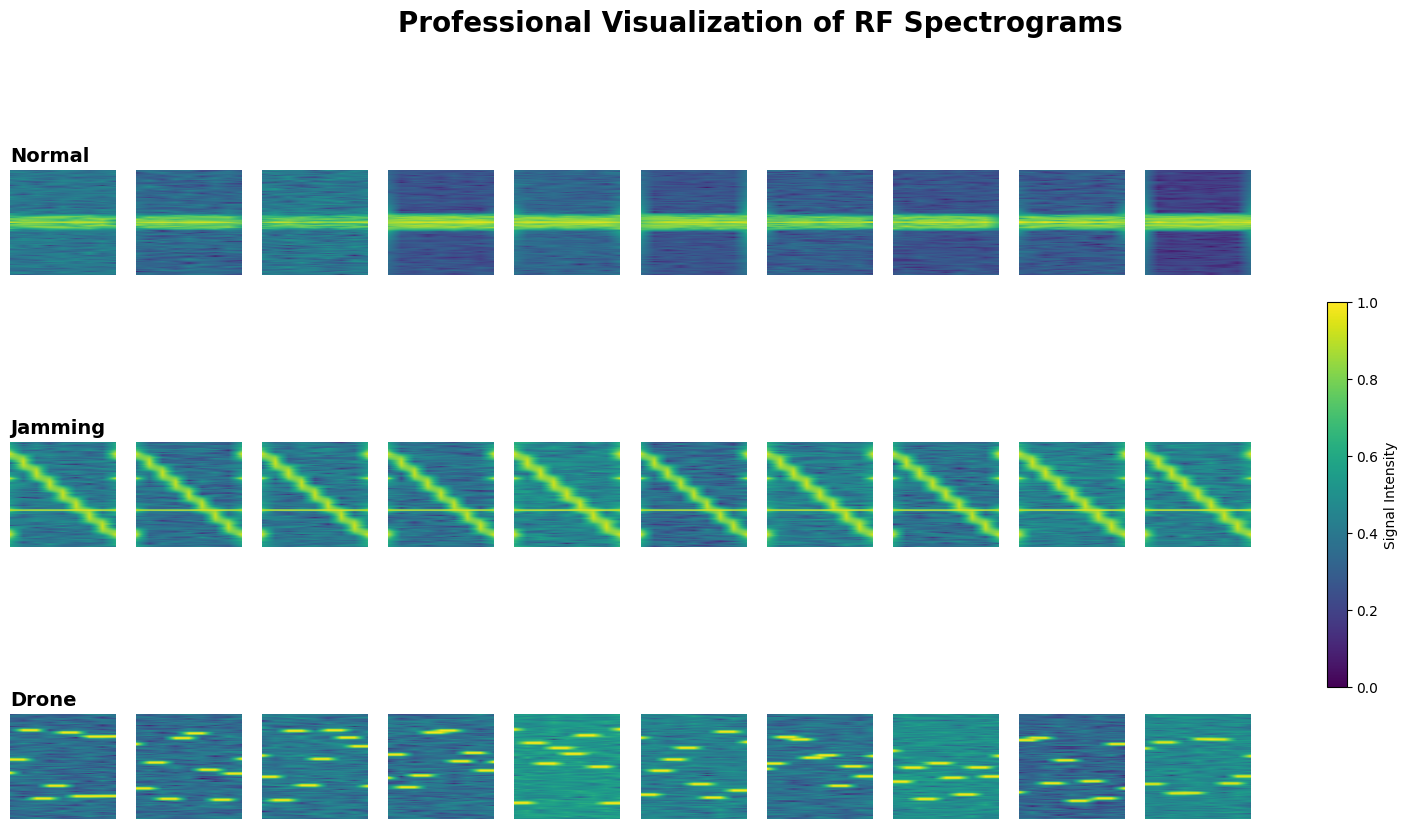

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# --- Data Loading Section ---
# Load pre-processed NumPy arrays from the local directory
X_train = np.load("/kaggle/working/dataset/X_train.npy")
y_train = np.load("/kaggle/working/dataset/y_train.npy")

# Define class labels for visualization mapping
labels = ["Normal", "Jamming", "Drone"]

# --- Visualization Setup ---
# Initialize a subplot grid (3 rows for classes x 10 columns for samples)
fig, axes = plt.subplots(3, 10, figsize=(20, 10))

for class_idx in range(3):
    # Filter indices to retrieve the first 10 occurrences of each specific class
    indices = np.where(y_train == class_idx)[0][:10]
    
    for i, img_idx in enumerate(indices):
        ax = axes[class_idx, i]
        
        # Technical Note: Extracting the first channel [:, :, 0] for visualization.
        # Although the data is stored in 3 channels for CNN compatibility, 
        # a single-channel heat-map (Color Map) provides better visual contrast.
        img_to_show = X_train[img_idx][:, :, 0] 
        
        # Apply 'viridis' colormap to represent signal intensity (Power Spectral Density)
        im = ax.imshow(img_to_show, cmap='viridis') 
        
        ax.axis('off') # Remove axis ticks for a cleaner presentation
        
        # Annotate the start of each row with the corresponding class name
        if i == 0:
            ax.set_title(labels[class_idx], loc='left', fontweight='bold', fontsize=14)

# --- Post-processing & Rendering ---
# Integrate a global colorbar to represent the normalized signal intensity scale
plt.colorbar(im, ax=axes.ravel().tolist(), shrink=0.5, label='Normalized Signal Intensity')

plt.suptitle("RF Spectrogram Feature Analysis: Class-wise Visualization", fontsize=20, fontweight='bold')
plt.tight_layout() # Optimize spacing between subplots
plt.show()

# Print dataset summary for verification
print(f"Visualization complete for {X_train.shape[0]} samples across {len(labels)} classes.")